# 03 — Validation Setup

Defines the walk-forward cross-validation strategy and evaluation helpers used by all model notebooks.

Standard k-fold shuffles data randomly, allowing the model to train on future data — this is leakage for time series. Walk-forward validation enforces that training always comes before testing.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              mean_squared_error, mean_absolute_error)

BASE_DIR  = "."
FEAT_DIR  = os.path.join(BASE_DIR, "data/features")
VAL_DIR   = os.path.join(BASE_DIR, "data/validation")
TICKERS   = ["AAPL", "MSFT", "JPM", "GS", "JNJ", "PFE", "SPOT", "AMZN", "TSLA"]

os.makedirs(VAL_DIR, exist_ok=True)
print("Imports done.")

Imports done.


## 1. Walk-forward splitter

Expanding window — each fold's training set includes all past data. 5 folds, 50% minimum training fraction.

```
Fold 1: Train [0-49%]  Test [50-59%]
Fold 2: Train [0-59%]  Test [60-69%]
Fold 3: Train [0-69%]  Test [70-79%]
Fold 4: Train [0-79%]  Test [80-89%]
Fold 5: Train [0-89%]  Test [90-100%]
```

In [2]:
def walk_forward_splits(df, n_splits=5, min_train_frac=0.5):
    n         = len(df)
    min_train = int(n * min_train_frac)
    test_size = (n - min_train) // n_splits
    splits    = []
    for i in range(n_splits):
        train_end  = min_train + i * test_size
        test_start = train_end
        test_end   = test_start + test_size
        if i == n_splits - 1:
            test_end = n
        splits.append((list(range(0, train_end)),
                       list(range(test_start, test_end))))
    return splits

print("walk_forward_splits defined.")

walk_forward_splits defined.


## 2. Evaluation helpers

In [3]:
def evaluate_classification(y_true, y_pred, fold=None):
    return {
        "Fold"     : fold,
        "Accuracy" : round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        "F1"       : round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

def evaluate_regression(y_true, y_pred, fold=None):
    return {
        "Fold": fold,
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 6),
        "MAE" : round(mean_absolute_error(y_true, y_pred), 6),
    }

print("Evaluation helpers defined.")

Evaluation helpers defined.


## 3. Verify splits on AAPL

In [4]:
sample_df = pd.read_csv(
    os.path.join(FEAT_DIR, "AAPL_features.csv"),
    index_col="Date", parse_dates=True
).sort_index()

splits = walk_forward_splits(sample_df, n_splits=5)

print(f"Walk-forward splits for AAPL ({len(sample_df)} rows)")
print(f"{'Fold':<6} {'Train rows':>11} {'Train end':>12} {'Test rows':>10} {'Test range':>30}")
print("-" * 75)
for i, (tr, te) in enumerate(splits):
    print(f"{i+1:<6} {len(tr):>11,} {str(sample_df.index[tr[-1]].date()):>12} "
          f"{len(te):>10,} {str(sample_df.index[te[0]].date()):>14} to {str(sample_df.index[te[-1]].date())}")

Walk-forward splits for AAPL (1312 rows)
Fold    Train rows    Train end  Test rows                     Test range
---------------------------------------------------------------------------
1              656   2023-09-08        131     2023-09-11 to 2024-03-18
2              787   2024-03-18        131     2024-03-19 to 2024-09-24
3              918   2024-09-24        131     2024-09-25 to 2025-04-03
4            1,049   2025-04-03        131     2025-04-04 to 2025-10-10
5            1,180   2025-10-10        132     2025-10-13 to 2026-04-22


## 4. Visualize splits

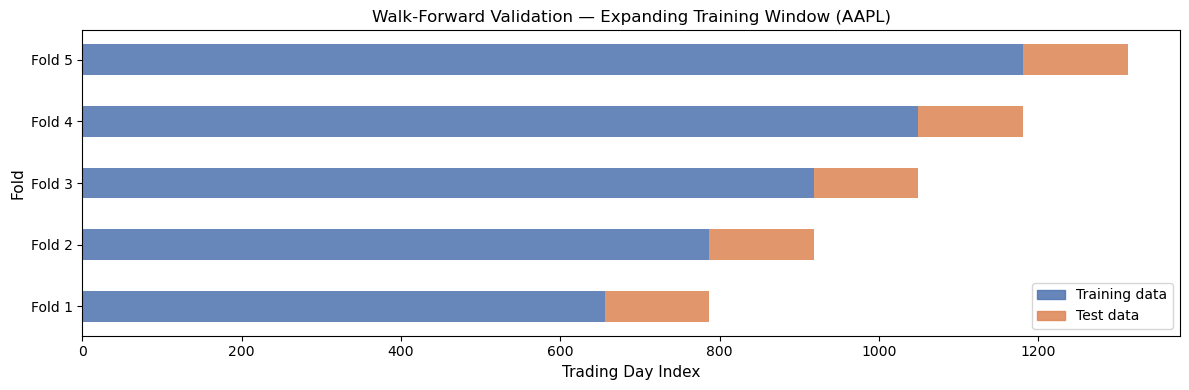

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
colors  = {"train": "#4C72B0", "test": "#DD8452"}

for i, (tr, te) in enumerate(splits):
    ax.barh(i + 1, len(tr), left=0,       height=0.5, color=colors["train"], alpha=0.85)
    ax.barh(i + 1, len(te), left=len(tr), height=0.5, color=colors["test"],  alpha=0.85)

ax.set_xlabel("Trading Day Index", fontsize=11)
ax.set_ylabel("Fold", fontsize=11)
ax.set_title("Walk-Forward Validation — Expanding Training Window (AAPL)", fontsize=12)
ax.set_yticks(range(1, len(splits) + 1))
ax.set_yticklabels([f"Fold {i+1}" for i in range(len(splits))])
ax.legend(handles=[
    mpatches.Patch(color=colors["train"], alpha=0.85, label="Training data"),
    mpatches.Patch(color=colors["test"],  alpha=0.85, label="Test data")
], loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(VAL_DIR, "walk_forward_splits.png"), dpi=120, bbox_inches="tight")
plt.show()

## 5. Confirm splits across all tickers

In [6]:
print(f"{'Ticker':<7} {'Total rows':>11}  " + "  ".join([f"Fold{i+1}_test" for i in range(5)]))
print("-" * 75)
for ticker in TICKERS:
    df    = pd.read_csv(os.path.join(FEAT_DIR, f"{ticker}_features.csv"),
                        index_col="Date", parse_dates=True).sort_index()
    sp    = walk_forward_splits(df, n_splits=5)
    sizes = "  ".join([f"{len(te):>10}" for _, te in sp])
    print(f"{ticker:<7} {len(df):>11}  {sizes}")

print("Notebook 03 complete — validation strategy ready.")

Ticker   Total rows  Fold1_test  Fold2_test  Fold3_test  Fold4_test  Fold5_test
---------------------------------------------------------------------------
AAPL           1312         131         131         131         131         132
MSFT           1312         131         131         131         131         132
JPM            1312         131         131         131         131         132
GS             1312         131         131         131         131         132
JNJ            1312         131         131         131         131         132
PFE            1312         131         131         131         131         132
SPOT           1312         131         131         131         131         132
AMZN           1312         131         131         131         131         132
TSLA           1312         131         131         131         131         132
Notebook 03 complete — validation strategy ready.
